# Ungraded Lab: Capstone Project Lab

## 📋 Overview 
Welcome to the Capstone Project Lab! In this comprehensive hands-on session, you'll apply all the SQL concepts you've learned throughout the course to analyze a complex dataset from TechMart, a growing retail chain. You'll clean data, write advanced queries, and produce a well-documented analysis report. This lab simulates real-world data analysis challenges, preparing you for your future career as a data scientist.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:
- Clean and prepare complex datasets using SQL
- Write advanced SQL queries involving subqueries, CTEs, and window functions
- Perform comprehensive data analysis across multiple related tables
- Leverage generative AI tools to optimize SQL queries and enhance performance
- Produce a well-documented data analysis report


## 📚 Dataset Information
You'll be working with the <b>TechMart</b> dataset, which contains information about a retail chain's operations across North America and Europe. The dataset includes:
- <b>Employee_Records:</b> Information about employees, their roles, and sales performance
- <b>Product_Details:</b> Details about products, including categories and inventory
- <b>Customer_Demographics:</b> Customer information and loyalty program status
- <b>Sales_Transactions:</b> Transaction data linking customers, products, and employees


## 🖥️ Activities

### Activity 1: Data Exploration and Cleaning 

Before diving into analysis, it's crucial to understand and clean our dataset. We'll start by examining each table and addressing any data quality issues.

<b>Step 1:</b> Connect to the database, then load and display tables:

In [1]:
import sqlite3
import pandas as pd

# Setting up the database. DO NOT edit the code given below
from techsmart_db_setup import setup_database
setup_database() 
conn = sqlite3.connect('techsmart.db')

# Load and display tables
tables = ['Employee_Records', 'Product_Details', 'Customer_Demographics', 'Sales_Transactions']
for table in tables:
    query = f"SELECT * FROM {table} LIMIT 5"
    df = pd.read_sql_query(query, conn)
    print(f"\n{table}:")
    display(df)

✅ Database setup complete: Tables created and populated with data!

Employee_Records:


,employee_id,role,store_location,sales_performance
0,1,Cashier,New York,None
1,2,Cashier,Los Angeles,3000
2,3,Supervisor,Phoenix,None
3,4,Manager,Chicago,3000
4,5,Manager,Phoenix,3000



Product_Details:


,product_id,product_name,category,price,stock
0,106,Tablet,Electronics,one hundred,200.0
1,101,Keyboard,Accessories,fifty,100.0
2,108,Keyboard,Accessories,fifty,500.0
3,104,Speaker,Electronics,500,150.0
4,107,Speaker,Electronics,fifty,300.0



Customer_Demographics:


,customer_id,age,gender,location,loyalty_program
0,1,35,F,San Antonio,None
1,2,50,M,London,No
2,3,37,M,Austin,No
3,4,None,M,San Antonio,None
4,5,28,M,San Antonio,None



Sales_Transactions:


,transaction_id,customer_id,product_id,employee_id,quantity,total_amount,sale_date
0,1,13.0,105,2.0,4,90.0,2025-03-03 00:00:00
1,2,37.0,105,51.0,2,90.0,2025-03-08 00:00:00
2,3,5.0,106a,NaN,three,NaN,2025-03-01 00:00:00
3,4,35.0,109b,22.0,three,40.0,2025-03-04 00:00:00
4,5,15.0,101,45.0,2,NaN,2025-03-06 00:00:00


<b>Step 2:</b> Identify and handle missing values:

In [2]:
# Example for Employee_Records
query = """
SELECT COUNT(*) as total_rows,
       SUM(CASE WHEN sales_performance IS NULL OR sales_performance = 'NaN' THEN 1 ELSE 0 END) as missing_sales
FROM Employee_Records
"""
df = pd.read_sql_query(query, conn)
display(df)

,total_rows,missing_sales
0,100,11


<b>Step 3: Try it yourself: </b>Write queries to identify missing values in other tables

In [3]:
# Your turn: Write queries to identify missing values in Employee_Records:
query = """
SELECT * 
FROM Employee_Records 
WHERE employee_id IS NULL 
   OR employee_id IS 'NaN' 
   OR role IS NULL
   OR role IS 'NaN'
   OR store_location IS NULL
   OR store_location IS 'NaN'
   OR sales_performance IS NULL
   OR sales_performance IS 'NaN';
"""
df = pd.read_sql_query(query, conn)
display(df)

,employee_id,role,store_location,sales_performance
0,1,Cashier,New York,None
1,3,Supervisor,Phoenix,None
2,26,Manager,New York,None
3,35,Sales Associate,Los Angeles,None
4,37,Cashier,London,None
5,45,Manager,Houston,None
6,46,Sales Associate,Los Angeles,None
7,68,Cashier,Los Angeles,None
8,69,Manager,London,None
9,76,Cashier,Los Angeles,None


### Results:
<b>Missing Values in Employee_Records: </b><br>'sales_performance''

In [4]:
query = """
SELECT COUNT(*) as 'Employee Records',
       SUM(CASE WHEN sales_performance IS NULL OR sales_performance = 'NaN' THEN 1 ELSE 0 END) as 'Missing Sales'
FROM Employee_Records
"""
df = pd.read_sql_query(query, conn)
display(df)

,Employee Records,Missing Sales
0,100,11


In [5]:
# Your turn: Write queries to identify missing values in Product_Details:
query = """
SELECT * 
FROM Product_Details 
WHERE product_id IS NULL 
   OR product_id IS 'NaN' 
   OR product_name IS NULL
   OR product_name IS 'NaN'
   OR category IS NULL
   OR category IS 'NaN'
   OR price IS NULL
   OR price IS 'NaN'
   OR stock IS NULL
   OR stock IS 'NaN'
"""
df = pd.read_sql_query(query, conn)
display(df)

,product_id,product_name,category,price,stock
0,104,Tablet,Accessories,None,500.0
1,109,Mouse,Accessories,None,500.0
2,109,Keyboard,Electronics,fifty,NaN
3,104,Keyboard,Accessories,200,NaN
4,107,Mouse,Accessories,300,NaN
5,110,Speaker,Accessories,200,NaN
6,105,Mouse,Electronics,25,NaN
7,110,Monitor,Electronics,500,NaN
8,109,Keyboard,Electronics,fifty,NaN
9,110,Laptop,Electronics,one hundred,NaN


### Results:
<b>Missing Values in Product_details: </b><br>'price'<br>'stock'

In [6]:
query = """
SELECT COUNT(*) as 'Product Details',
       SUM(CASE WHEN price IS NULL OR price = 'NaN' THEN 1 ELSE 0 END) as 'Missing Price',
       SUM(CASE WHEN stock IS NULL OR stock = 'NaN' THEN 1 ELSE 0 END) as 'Missing Stock'
FROM Product_details;
"""
df = pd.read_sql_query(query, conn)
display(df)

,Product Details,Missing Price,Missing Stock
0,100,8,19


In [7]:
# Your turn: Write queries to identify missing values in Customer_Demographics:
query = """
SELECT * 
FROM Customer_Demographics 
WHERE customer_id IS NULL 
   OR customer_id IS 'NaN' 
   OR age IS NULL
   OR age IS 'NaN'
   OR gender IS NULL
   OR gender IS 'NaN'
   OR location IS NULL
   OR location IS 'NaN'
   OR loyalty_program IS NULL
   OR loyalty_program IS 'NaN'
"""
df = pd.read_sql_query(query, conn)
display(df)

,customer_id,age,gender,location,loyalty_program
0,1,35,F,San Antonio,None
1,4,None,M,San Antonio,None
2,5,28,M,San Antonio,None
3,8,None,M,San Jose,No
4,10,41,F,Austin,None
5,13,37,F,London,None
6,14,None,F,San Antonio,No
7,16,22,M,New York,None
8,17,35,M,San Antonio,None
9,25,22,M,Los Angeles,None


### Results:
<b>Missing Values in Customer_Demographics:</b><br>'age'<br>'loyalty_program'

In [8]:
query = """
SELECT COUNT(*) as 'Customer Demographics',
       SUM(CASE WHEN age IS NULL OR age = 'NaN' THEN 1 ELSE 0 END) as 'Missing Age',
       SUM(CASE WHEN loyalty_program IS NULL OR loyalty_program = 'NaN' THEN 1 ELSE 0 END) as 'Missing Loyalty Program'
FROM Customer_Demographics;
"""
df = pd.read_sql_query(query, conn)
display(df)

,Customer Demographics,Missing Age,Missing Loyalty Program
0,100,12,35


In [9]:
# Your turn: Write queries to identify missing values in Sales_Transactions:
query = """
SELECT * 
FROM Sales_Transactions 
WHERE transaction_id IS NULL 
   OR transaction_id IS 'NaN' 
   OR customer_id IS NULL
   OR customer_id IS 'NaN'
   OR product_id IS NULL
   OR product_id IS 'NaN'
   OR employee_id IS NULL
   OR employee_id IS 'NaN'
   OR quantity IS NULL
   OR quantity IS 'NaN'
   OR total_amount IS NULL
   OR total_amount IS 'NaN'
   OR sale_date IS NULL
   OR sale_date IS 'NaN'
"""
df = pd.read_sql_query(query, conn)
display(df)

,transaction_id,customer_id,product_id,employee_id,quantity,total_amount,sale_date
0,3,5.0,106a,NaN,three,NaN,2025-03-01 00:00:00
1,5,15.0,101,45.0,2,NaN,2025-03-06 00:00:00
2,8,13.0,102,39.0,three,NaN,2025-03-05 00:00:00
3,13,3.0,105,25.0,2,NaN,2025-03-04 00:00:00
4,15,NaN,109b,39.0,1,50.0,2025-03-05 00:00:00
5,17,NaN,103,NaN,2,NaN,2025-03-05 00:00:00
6,18,51.0,101,37.0,None,40.0,2025-03-04 00:00:00
7,19,3.0,101,37.0,three,NaN,2025-03-03 00:00:00
8,23,5.0,109b,37.0,None,50.0,2025-03-10 00:00:00
9,33,46.0,104,51.0,None,90.0,2025-03-10 00:00:00


### Results:
<b>Missing Values in Sales_Transactions:</b><br>'customer_id'<br>'employee_id'<br>'quantity'<br>'total_amount'

In [10]:
query = """
SELECT COUNT(*) as 'Sales Transactions',
       SUM(CASE WHEN customer_id IS NULL OR customer_id = 'NaN' 
           THEN 1 ELSE 0 END) as 'Missing Customer ID',
       SUM(CASE WHEN employee_id IS NULL OR employee_id = 'NaN' 
           THEN 1 ELSE 0 END) as 'Missing Employee ID',
       SUM(CASE WHEN quantity IS NULL OR quantity = 'NaN' 
           THEN 1 ELSE 0 END) as 'Missing Quantity',         
       SUM(CASE WHEN total_amount IS NULL OR total_amount = 'NaN' 
           THEN 1 ELSE 0 END) as 'Missing Total'
FROM Sales_Transactions;
"""
df = pd.read_sql_query(query, conn)
display(df)

,Sales Transactions,Missing Customer ID,Missing Employee ID,Missing Quantity,Missing Total
0,100,7,7,17,16


<b>Step 4:</b> Clean inconsistent data formats:

<b>Example: Standardize sales_performance in Employee_Records:</b><br><br>
query = """<br>
UPDATE Employee_Records<br>
SET sales_performance = CASE<br>
    WHEN sales_performance = 'nan' THEN NULL<br>
    WHEN sales_performance = 'five thousand' THEN '5000'<br>
    ELSE sales_performance<br>
END<br>
"""<br>
cursor = conn.cursor()<br>
cursor.execute(query)<br>
conn.commit()

**Step 5: Try it yourself:** Clean inconsistent data in other tables


<b>💡 Tip:</b> Use CASE statements to handle multiple conditions when cleaning data.

In [11]:
# Your turn: Clean inconsistent data in Employee_Records:

prag = pd.read_sql_query("PRAGMA table_info(Employee_Records)", conn)
display(prag)

query = """
SELECT DISTINCT(role)
FROM Employee_Records
"""
query2 = """
SELECT DISTINCT(store_location)
FROM Employee_Records
"""
query3 = """
SELECT DISTINCT(sales_performance)
FROM Employee_Records
"""

df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,cid,name,type,notnull,dflt_value,pk
0,0,employee_id,INTEGER,0,None,0
1,1,role,TEXT,0,None,0
2,2,store_location,TEXT,0,None,0
3,3,sales_performance,TEXT,0,None,0


,role,store_location,sales_performance
0,Cashier,New York,None
1,Supervisor,Los Angeles,3000
2,Manager,Phoenix,2000
3,Sales Associate,Chicago,1000
4,NaN,Paris,five thousand
5,NaN,London,NaN
6,NaN,Houston,NaN


In [12]:
query = """
UPDATE Employee_Records
SET sales_performance = 
    CASE WHEN sales_performance = 'nan' THEN NULL
         WHEN sales_performance = 'five thousand' THEN '5000'
         ELSE sales_performance END
"""
cursor = conn.cursor()
cursor.execute(query)
conn.commit()

query = """
SELECT DISTINCT(role)
FROM Employee_Records
"""
query2 = """
SELECT DISTINCT(store_location)
FROM Employee_Records
"""
query3 = """
SELECT DISTINCT(sales_performance)
FROM Employee_Records
"""

df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,role,store_location,sales_performance
0,Cashier,New York,None
1,Supervisor,Los Angeles,3000
2,Manager,Phoenix,2000
3,Sales Associate,Chicago,1000
4,NaN,Paris,5000
5,NaN,London,NaN
6,NaN,Houston,NaN


In [13]:
# Your turn: Clean inconsistent data in Product_Details:

prag = pd.read_sql_query("PRAGMA table_info(Product_Details)", conn)
display(prag)

query = """
SELECT DISTINCT(product_name)
FROM Product_Details
"""
query2 = """
SELECT DISTINCT(category)
FROM Product_Details
"""
query3 = """
SELECT DISTINCT(price)
FROM Product_Details
"""
query4 = """
SELECT DISTINCT(stock)
FROM Product_Details
"""

df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query4, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,cid,name,type,notnull,dflt_value,pk
0,0,product_id,INTEGER,0,None,0
1,1,product_name,TEXT,0,None,0
2,2,category,TEXT,0,None,0
3,3,price,TEXT,0,None,0
4,4,stock,REAL,0,None,0


,product_name,category,price,stock
0,Tablet,Electronics,one hundred,200.0
1,Keyboard,Accessories,fifty,100.0
2,Speaker,NaN,500,500.0
3,Mouse,NaN,None,150.0
4,Charger,NaN,25,300.0
5,Monitor,NaN,40,NaN
6,Laptop,NaN,200,50.0
7,Camera,NaN,300,NaN
8,Smartphone,NaN,150,NaN
9,Headphones,NaN,NaN,NaN


In [14]:
query = """
UPDATE Product_Details

SET price =
    CASE WHEN price = 'fifty' THEN '50'
         WHEN price = 'one hundred' THEN '100'
         ELSE price
    END,
    
    stock =    
    CASE WHEN stock = 'nan' THEN NULL
         ELSE stock
    END;   
"""

cursor = conn.cursor()
cursor.execute(query)
conn.commit()

query = """
SELECT DISTINCT(product_name)
FROM Product_Details
"""
query2 = """
SELECT DISTINCT(category)
FROM Product_Details
"""
query3 = """
SELECT DISTINCT(price)
FROM Product_Details
"""
query4 = """
SELECT DISTINCT(stock)
FROM Product_Details
"""

df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query4, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,product_name,category,price,stock
0,Tablet,Electronics,100,200.0
1,Keyboard,Accessories,50,100.0
2,Speaker,NaN,500,500.0
3,Mouse,NaN,None,150.0
4,Charger,NaN,25,300.0
5,Monitor,NaN,40,NaN
6,Laptop,NaN,200,50.0
7,Camera,NaN,300,NaN
8,Smartphone,NaN,150,NaN
9,Headphones,NaN,NaN,NaN


In [15]:
# Your turn: Clean inconsistent data in Customer_Demographics:

prag = pd.read_sql_query("PRAGMA table_info(Customer_Demographics)", conn)
display(prag)

query = """
SELECT DISTINCT(gender)
FROM Customer_Demographics
"""
query2 = """
SELECT DISTINCT(location)
FROM Customer_Demographics
"""
query3 = """
SELECT DISTINCT(loyalty_program)
FROM Customer_Demographics
"""
query4 = """
SELECT DISTINCT(age)
FROM Customer_Demographics
"""

df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query4, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,cid,name,type,notnull,dflt_value,pk
0,0,customer_id,INTEGER,0,None,0
1,1,age,TEXT,0,None,0
2,2,gender,TEXT,0,None,0
3,3,location,TEXT,0,None,0
4,4,loyalty_program,TEXT,0,None,0


,gender,location,loyalty_program,age
0,F,San Antonio,None,35
1,M,London,No,50
2,NaN,Austin,Yes,37
3,NaN,Los Angeles,NaN,None
4,NaN,New York,NaN,28
5,NaN,San Jose,NaN,25
6,NaN,Paris,NaN,43
7,NaN,Houston,NaN,42
8,NaN,Chicago,NaN,41
9,NaN,Phoenix,NaN,40


In [16]:
query = """
UPDATE Customer_Demographics

SET age =
    CASE WHEN age = 'thirty-five' THEN '35'
         ELSE age
    END;
"""

cursor = conn.cursor()
cursor.execute(query)
conn.commit()


query = """
SELECT DISTINCT(gender)
FROM Customer_Demographics
"""
query2 = """
SELECT DISTINCT(location)
FROM Customer_Demographics
"""
query3 = """
SELECT DISTINCT(loyalty_program)
FROM Customer_Demographics
"""
query4 = """
SELECT DISTINCT(age)
FROM Customer_Demographics
"""

df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query4, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,gender,location,loyalty_program,age
0,F,San Antonio,None,35
1,M,London,No,50
2,NaN,Austin,Yes,37
3,NaN,Los Angeles,NaN,None
4,NaN,New York,NaN,28
5,NaN,San Jose,NaN,25
6,NaN,Paris,NaN,43
7,NaN,Houston,NaN,42
8,NaN,Chicago,NaN,41
9,NaN,Phoenix,NaN,40


In [17]:
# Your turn: Clean inconsistent data in Sales_Transactions:

prag = pd.read_sql_query("PRAGMA table_info(Sales_Transactions)", conn)
display(prag)

query = """
SELECT DISTINCT(product_id)
FROM Sales_Transactions
"""
query2 = """
SELECT DISTINCT(quantity)
FROM Sales_Transactions
"""
query3 = """
SELECT DISTINCT(total_amount)
FROM Sales_Transactions
"""

df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,cid,name,type,notnull,dflt_value,pk
0,0,transaction_id,INTEGER,0,None,0
1,1,customer_id,REAL,0,None,0
2,2,product_id,TEXT,0,None,0
3,3,employee_id,REAL,0,None,0
4,4,quantity,TEXT,0,None,0
5,5,total_amount,REAL,0,None,0
6,6,sale_date,TEXT,0,None,0


,product_id,quantity,total_amount
0,105,4,90.0
1,106a,2,NaN
2,109b,three,40.0
3,101,1,60.0
4,103,3,50.0
5,102,None,30.0
6,104,NaN,NaN


In [18]:
query = """
UPDATE Sales_Transactions

SET product_id =
    CASE WHEN product_id = '106a' THEN '106'
         WHEN product_id = '109b' THEN '109'
         ELSE product_id
    END,
    
    quantity =
    CASE WHEN quantity = 'three' THEN '3'
         ELSE quantity
    END,
    
    total_amount =
    CASE WHEN total_amount = 'nan' THEN NULL
         ELSE total_amount
    END;
"""

cursor = conn.cursor()
cursor.execute(query)
conn.commit()

query = """
SELECT DISTINCT(product_id)
FROM Sales_Transactions
"""
query2 = """
SELECT DISTINCT(quantity)
FROM Sales_Transactions
"""
query3 = """
SELECT DISTINCT(total_amount)
FROM Sales_Transactions
"""

df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,product_id,quantity,total_amount
0,105,4,90.0
1,106,2,NaN
2,109,3,40.0
3,101,1,60.0
4,103,None,50.0
5,102,NaN,30.0
6,104,NaN,NaN


### Activity 2: Advanced Data Analysis  

Now that our data is clean, let's perform some advanced analysis to gain insights into TechMart's operations.

<b>Step 1:</b> Analyze employee performance by location:

In [19]:
query = """
WITH emp_sales AS (
    SELECT store_location, 
           AVG(CAST(sales_performance AS FLOAT)) as avg_sales,
           COUNT(*) as employee_count
    FROM Employee_Records
    WHERE sales_performance IS NOT NULL
    GROUP BY store_location
)
SELECT store_location, avg_sales, employee_count,
       RANK() OVER (ORDER BY avg_sales DESC) as location_rank
FROM emp_sales
ORDER BY avg_sales DESC
"""
df = pd.read_sql_query(query, conn)
display(df)

,store_location,avg_sales,employee_count,location_rank
0,Chicago,3875.000000,8,1
1,Phoenix,3312.500000,16,2
2,London,3214.285714,14,3
3,New York,2823.529412,17,4
4,Los Angeles,2692.307692,13,5
5,Paris,2600.000000,10,6
6,Houston,2363.636364,11,7


<b>Step 2:</b> Identify top-selling products by category:

In [20]:
query = """
SELECT *
FROM (
    SELECT p.category,
           p.product_name,
           SUM(s.quantity) AS total_sold,
           RANK() OVER (
               PARTITION BY p.category
               ORDER BY SUM(s.quantity) DESC
           ) AS rank_in_category
    FROM Sales_Transactions s
    JOIN Product_Details p ON s.product_id = p.product_id
    GROUP BY p.category, p.product_name
)
WHERE rank_in_category <= 3
ORDER BY category, total_sold DESC
"""
df = pd.read_sql_query(query, conn)
display(df)

,category,product_name,total_sold,rank_in_category
0,Accessories,Charger,219,1
1,Accessories,Keyboard,211,2
2,Accessories,Monitor,110,3
3,Electronics,Tablet,268,1
4,Electronics,Mouse,180,2
5,Electronics,Headphones,125,3


 <b>Step 3: Try it yourself</b>  Analyze customer purchasing behavior:

## Make a plan

<b>Part #1</b><br>

For the analysis of customer purchasing behavior we will require data from 3 of our tables:<br>
-Customer_Demographics<br>
-Sales_Transactions<br>
-Product_Details<br><br>

We'll use two windows to join these tables in two steps:<br>
-Customer_Transactions<br>
-Product_Sales<br><br>

In [21]:
# Your turn: Write a query to analyze customer purchasing behavior
# Hint: Join Customer_Demographics with Sales_Transactions and use window functions

query = """

WITH 
    Product_Info AS(
    
        SELECT product_id,
               category,
               product_name,
               price
        FROM Product_Details
        GROUP BY product_id
),
    Sales_Info AS(
           SELECT s.transaction_id,
                  s.customer_id,
                  s.product_id,
                  p.category,
                  p.product_name,
                  p.price,
                  s.quantity,
                  s.sale_date
           FROM Sales_Transactions s
           LEFT JOIN Product_Info p ON p.product_id = s.product_id
           ORDER BY s.transaction_id
),
    Customer_Info AS(
           SELECT c.location,
                  c.customer_id,
                  c.age,
                  c.gender                 
           FROM Customer_Demographics c
           GROUP BY c.customer_id
)

SELECT s.transaction_id,
       s.customer_id,
       s.product_id,
       s.category,
       s.product_name,
       s.quantity,
       s.price,
       c.location,
       c.age,
       c.gender,
       s.sale_date
FROM Sales_Info s 
LEFT JOIN Customer_Info c ON c.customer_id = s.customer_id
WHERE s.customer_id NOT NULL AND s.price NOT NULL
GROUP BY s.transaction_id
ORDER BY s.transaction_id;
"""
df = pd.read_sql_query(query, conn)
display(df)

,transaction_id,customer_id,product_id,category,product_name,quantity,price,location,age,gender,sale_date
0,1,13.0,105,Accessories,Monitor,4,200,London,37,F,2025-03-03 00:00:00
1,2,37.0,105,Accessories,Monitor,2,200,Chicago,55,F,2025-03-08 00:00:00
2,3,5.0,106,Electronics,Tablet,3,100,San Antonio,28,M,2025-03-01 00:00:00
3,5,15.0,101,Accessories,Keyboard,2,50,Houston,30,F,2025-03-06 00:00:00
4,6,4.0,103,Electronics,Monitor,1,500,San Antonio,None,M,2025-03-09 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...
79,96,4.0,102,Electronics,Charger,4,25,San Antonio,None,M,2025-03-10 00:00:00
80,97,37.0,104,Electronics,Speaker,1,500,Chicago,55,F,2025-03-07 00:00:00
81,98,15.0,103,Electronics,Monitor,4,500,Houston,30,F,2025-03-04 00:00:00
82,99,41.0,106,Electronics,Tablet,4,100,Houston,22,M,2025-03-05 00:00:00


<b>Part #2</b><br>

Use Pandas to create dataframes which will be used to create data visualizations.<br><br>

In [22]:
df.dtypes

transaction_id      int64
customer_id       float64
product_id         object
category           object
product_name       object
quantity           object
price              object
location           object
age                object
gender             object
sale_date          object
dtype: object

In [23]:
#df['transaction_id'] can remain type "int64" because it is not allowed to be NULL
df['customer_id'] = df['customer_id'].astype("Int64")
df['sale_date'] = pd.to_datetime(df['sale_date'])
df['product_id'] = pd.to_numeric(df['product_id']).astype("Int64")
df['quantity'] = pd.to_numeric(df['quantity']).astype("Int64")
df['price'] = pd.to_numeric(df['price']).astype("Int64")
df['age'] = pd.to_numeric(df['age']).astype("Int64")
df['category'] = df['category'].astype('string')
df['product_name'] = df['product_name'].astype('string')
df['location'] = df['location'].astype('string')
df['gender'] = df['gender'].astype('string')

df.dtypes

transaction_id             int64
customer_id                Int64
product_id                 Int64
category                  string
product_name              string
quantity                   Int64
price                      Int64
location                  string
age                        Int64
gender                    string
sale_date         datetime64[ns]
dtype: object

In [24]:
df['revenue'] = df['quantity'].mul(df['price'])
df.head()

,transaction_id,customer_id,product_id,category,product_name,quantity,price,location,age,gender,sale_date,revenue
0,1,13,105,Accessories,Monitor,4,200,London,37,F,2025-03-03,800
1,2,37,105,Accessories,Monitor,2,200,Chicago,55,F,2025-03-08,400
2,3,5,106,Electronics,Tablet,3,100,San Antonio,28,M,2025-03-01,300
3,5,15,101,Accessories,Keyboard,2,50,Houston,30,F,2025-03-06,100
4,6,4,103,Electronics,Monitor,1,500,San Antonio,<NA>,M,2025-03-09,500


## Create Visualiztions of Customer Purchasing Behavior
### Using Matplotlib

In [25]:
import matplotlib.pyplot as plt
from matplotlib import colors

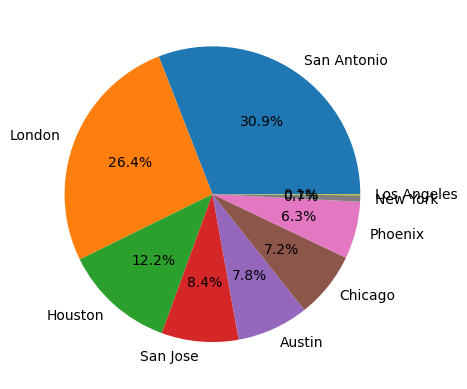

In [26]:
### Pie Chart Showing Total Sales Value By Location
df_city = df.groupby('location')['revenue'].sum().sort_values(ascending=False)

labels = df_city.index
sizes = df_city.values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%',
       labeldistance=1.1)
plt.show()
plt.close()

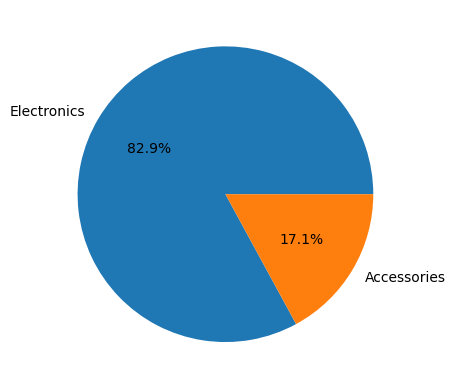

In [27]:
### Pie Chart Showing Total Sales Value Category
df_city = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

labels = df_city.index
sizes = df_city.values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%',
       labeldistance=1.1)
plt.show()
plt.close()

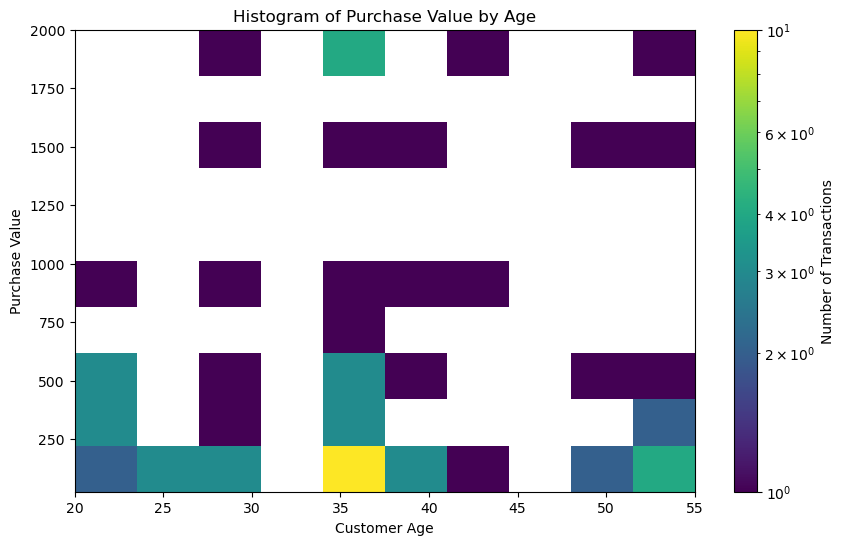

In [28]:
### Histogram of Purchase Value by Age
df_hist = df[['age', 'revenue']].dropna()


plt.figure(figsize=(10, 6))
plt.hist2d(df_hist['age'], df_hist['revenue'], norm=colors.LogNorm())

plt.title('Histogram of Purchase Value by Age')
plt.xlabel('Customer Age')
plt.ylabel('Purchase Value')
plt.colorbar().set_label('Number of Transactions')
plt.show()
plt.close()

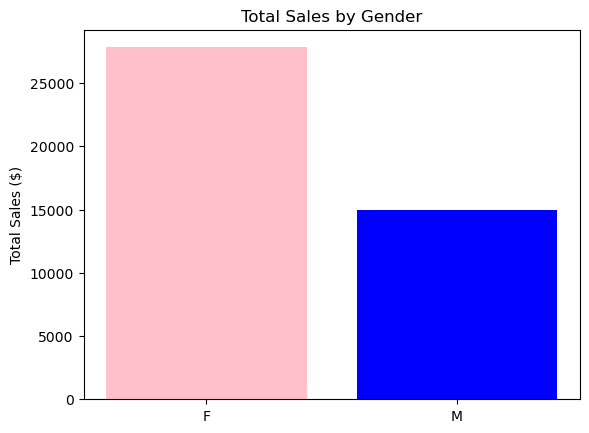

In [29]:
### Total Sales by Gender
df_gender = df.groupby('gender')['revenue'].sum()

fig, ax = plt.subplots()

gender = df_gender.index
total_sales = df_gender.values
bar_colors = ['pink', 'blue']

ax.bar(gender, total_sales, label=gender, color=bar_colors)

plt.title('Total Sales by Gender')
plt.ylabel('Total Sales ($)')
plt.show()
plt.close()

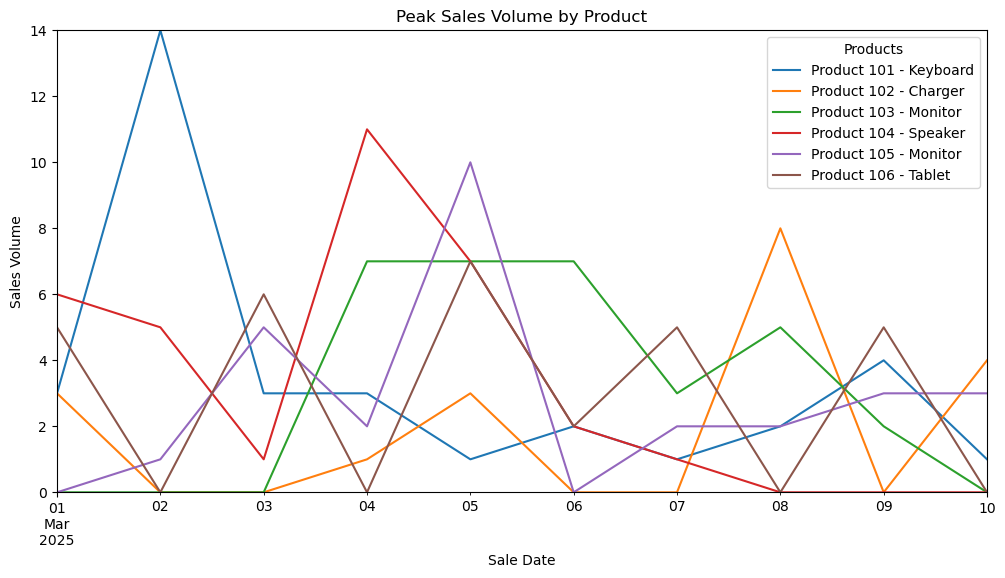

In [36]:
### Individual Product Sales by Month
import matplotlib.scale as mscale
import numpy as np

df_sales = df[['product_id', 'product_name', 'quantity', 'sale_date']]
df_pivot = df_sales.pivot_table(index='sale_date',
                                columns='product_id',
                                values='quantity',
                                aggfunc='sum',
                                fill_value=0)

name_map = df_sales.set_index('product_id')['product_name'].to_dict()

fig, ax = plt.subplots(figsize=(12,6))
df_pivot.plot(ax=ax)

ax.set_ylim(bottom=0, top=df_pivot.values.max() * 1)
#ax.set_yscale('function', functions=(lambda x: x**np.e, lambda x: np.log(x)))
ax.legend([f"Product {pid} - {name_map.get(pid, 'Unknown')}" for pid in df_pivot.columns], title="Products")

plt.title('Peak Sales Volume by Product')
ax.set_xlabel("Sale Date")
plt.ylabel('Sales Volume')
plt.show()
plt.close()

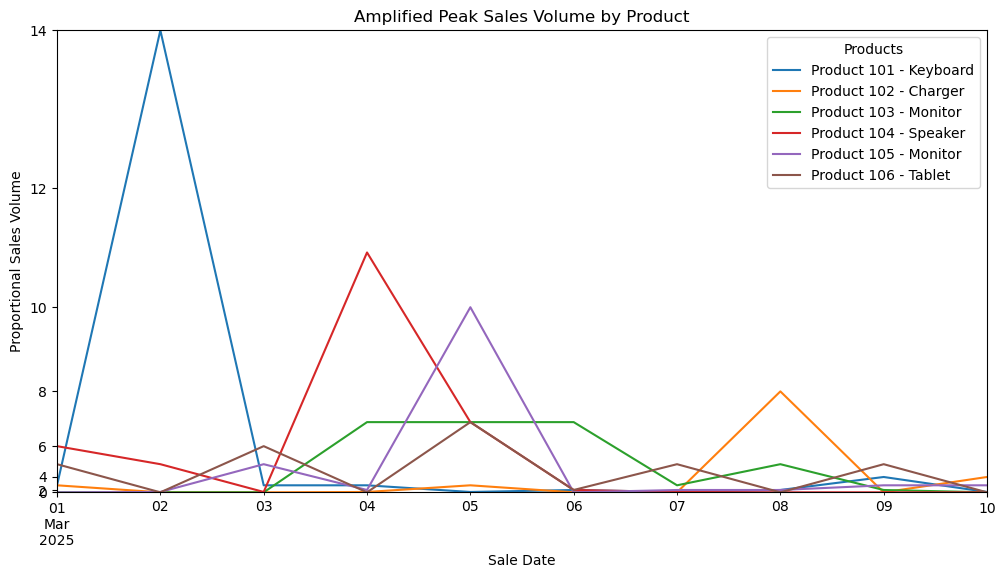

In [35]:
### Individual Product Sales by Month
import matplotlib.scale as mscale
import numpy as np

df_sales = df[['product_id', 'product_name', 'quantity', 'sale_date']]
df_pivot = df_sales.pivot_table(index='sale_date',
                                columns='product_id',
                                values='quantity',
                                aggfunc='sum',
                                fill_value=0)

name_map = df_sales.set_index('product_id')['product_name'].to_dict()

fig, ax = plt.subplots(figsize=(12,6))
df_pivot.plot(ax=ax)

ax.set_ylim(bottom=0, top=df_pivot.values.max() * 1)
ax.set_yscale('function', functions=(lambda x: x**np.e, lambda x: np.log(x)))
ax.legend([f"Product {pid} - {name_map.get(pid, 'Unknown')}" for pid in df_pivot.columns], title="Products")

plt.title('Amplified Peak Sales Volume by Product')
ax.set_xlabel("Sale Date")
plt.ylabel('Proportional Sales Volume')
plt.show()
plt.close()

### Activity 3: Performance Optimization 
As our dataset grows, query performance becomes crucial. Let's optimize some of our complex queries. The below query analyzes sales performance for Electronics and Accessories by summarizing transactions per employee, store, and customer loyalty status, while also computing total revenue per store-category pair for ranking and comparison.


<b>Step 1:</b> Identify slow-running queries:

In [ ]:
# Example: Time a complex query
import time

start_time = time.time()
query = """
WITH StoreSales AS (
   SELECT
       e.store_location,
       e.employee_id,
       e.role,
       p.category,
       c.loyalty_program,
       COUNT(s.transaction_id) AS total_sales,
       SUM(s.quantity) AS total_units_sold,
       SUM(s.total_amount) AS total_revenue
   FROM Sales_Transactions s
   JOIN Employee_Records e ON s.employee_id = e.employee_id
   JOIN Product_Details p ON s.product_id = p.product_id
   JOIN Customer_Demographics c ON s.customer_id = c.customer_id
   WHERE p.category IN ('Electronics', 'Accessories')
   GROUP BY e.store_location, e.employee_id, e.role, p.category, c.loyalty_program
),

StoreRankings AS (
   SELECT
       store_location,
       category,
       SUM(total_revenue) AS store_revenue
   FROM StoreSales
   GROUP BY store_location, category
)

SELECT
   ss.store_location,
   ss.employee_id,
   ss.role,
   ss.category,
   ss.loyalty_program,
   ss.total_sales,
   ss.total_units_sold,
   ss.total_revenue
FROM StoreSales ss
JOIN StoreRankings sr ON ss.store_location = sr.store_location AND ss.category = sr.category
ORDER BY ss.store_location, ss.total_revenue DESC;

"""


df = pd.read_sql_query(query, conn)
end_time = time.time()
print(f"Query execution time: {end_time - start_time} seconds")

<b>Step 2:</b> Add an index to optimize your query:

In [ ]:
# Create an index
cursor.execute("CREATE INDEX idx_product_category ON Product_Details(category)")
conn.commit()

<b>Step 3:</b> Use an AI to further optimize your query.

Using an AI of your choice, further optimize your query then paste your updated query into the cell in Step 4.


<b>Prompt:</b>

<b>Response:</b>

**Step 4: Try it yourself:** Re-run your query and compare execution time

In [ ]:
# Your Turn: Run your optimized query and compare execution time

start_time = time.time()
query = """
<YOUR CODE HERE>
"""

df = pd.read_sql_query(query, conn)
end_time = time.time()
print(f"Query execution time: {end_time - start_time} seconds")

<b>💡 Tip:</b> Indexes can significantly improve query performance, but they also have overhead. Use them judiciously.

### Activity 4: Generating the Analysis Report  

Now that we've performed our analysis, it's time to compile our findings into a comprehensive report.

<b>Step 1:</b> Summarize key findings:
- List the top 3 insights from your analysis
- Provide supporting data for each insight

<b>Step 2:</b> Include SQL queries:
- For each key insight, provide the SQL query used

<b>Step 3:</b> Document your process:
- Explain your data cleaning steps
- Describe any challenges you encountered and how you overcame them
- Discuss potential areas for further analysis

#### Close the Connection
It's good practice to close the database connection when you're done

In [ ]:
# Close the database connection 
conn.close()

## ✅ Success Checklist
- Cleaned and prepared all dataset tables
- Performed at least 3 advanced SQL queries using subqueries, CTEs, or window functions
- Optimized at least one complex query for better performance
- Compiled a comprehensive analysis report with key insights and supporting data
- Program runs without errors

## 🔍 Common Issues & Solutions 

- Problem: Query returns no results 
    - Solution: Double-check table and column names, and ensure your JOIN conditions are correct
- Problem: Error "no such table" 
     - Solution: Verify that you're connected to the correct database and that the table name is spelled correctly

## ➡️ Summary
In this comprehensive lab, you've applied advanced SQL concepts to analyze TechMart's retail operations data, working with multiple related tables covering employee records, product details, customer demographics, and sales transactions. You've gained hands-on experience in data cleaning, writing complex queries using subqueries, CTEs, and window functions, and optimizing query performance through indexing. Through this real-world simulation, you've developed the practical skills needed to conduct thorough data analysis and create well-documented reports, preparing you for actual data science roles.


### 🔑 Key Points
- Data cleaning is crucial for accurate analysis
- Advanced SQL techniques like CTEs and window functions enable complex analysis
- Query optimization is essential for working with large datasets
- Effective reporting is key to communicating insights